# <Model> vision on <N>x CMP 170HX (SM80) — <topology>, <runtime>

| Metric | Value |
|---|---|
| Decode, c=1 | <value> tok/s |
| Best aggregate | <value> tok/s at c=<n> |
| Prefill | <value> tok/s at <n> prompt tokens |
| TTFT | <value> s |

![proof image: fixture + model answer](../assets/images/<experiment>-proof.png)
<model's one-line answer under the image, quoted verbatim from the receipt>

```
<one-line pull command: hf download <model> ... or docker pull ...>
```

[<Release, evidence repo, or collection link>](<url>)

Fill every `<placeholder>` from a receipt under `results/<experiment>/`. Do
not invent a number. If there is no PASS yet, replace the table with an
honest in-progress status instead. Delete this instruction line before
publishing.


# TEMPLATE-vision — vision-experiment notebook

Copy this file to `notebooks/YYYY-MM-DD-<model>-<topology>-<runtime>.ipynb`
for any experiment that sends image input. See `notebooks/README.md` for
the four-section schema. Do not invent a number that is not in a receipt
under `results/<experiment>/`.

Reading order: TL;DR, then visible results, then reproduce steps. Failure
history and architecture detail live in the collapsed appendix at the end.


In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/<experiment>/.
# LIVE = True calls a running OpenAI-compatible vision endpoint. The
# endpoint URL comes from an environment variable; never hardcode an
# address in this notebook.
import os

EXPERIMENT = "TEMPLATE-vision"  # matches this notebook's filename, no extension
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
VISION_ENDPOINT = os.environ.get("VISION_ENDPOINT", "http://127.0.0.1:18099/v1")

print(f"experiment      : {EXPERIMENT}")
print(f"results_dir     : {RESULTS_DIR}")
print(f"LIVE            : {LIVE}")
if LIVE:
    print(f"vision_endpoint : {VISION_ENDPOINT}")
else:
    print("vision_endpoint : n/a (replaying committed receipts)")


experiment      : TEMPLATE-vision
results_dir     : ../results/TEMPLATE-vision
LIVE            : False
vision_endpoint : n/a (replaying committed receipts)


In [2]:
# --- Helpers: receipts, tables, hashing -----------------------------------
import hashlib
import json
import os

from IPython.display import display, Markdown


def load_receipt(name, results_dir=RESULTS_DIR):
    """Load one JSON receipt. Returns None (and prints a notice) if it does
    not exist yet, or if it is a placeholder stub (status == 'not run')."""
    path = os.path.join(results_dir, name)
    if not os.path.exists(path):
        print(f"no receipts yet: {path} does not exist")
        return None
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, dict) and data.get("status") == "not run":
        print(f"no receipts yet: {path} is a placeholder stub")
        return None
    return data


def render_table(headers, rows):
    """Render a list-of-lists as a Markdown table. Every header should
    carry its unit, e.g. 'Decode (tok/s)'."""
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


def sha256_of(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()


## 1. TL;DR

Nothing above this but the title and the status cell. Fill this table and
the pins table from `results/<experiment>/summary.json` and
`vision-gates.json` once a run exists; this copy of the template has no
run behind it, so every value below reads "not captured in receipts".


In [3]:
summary = load_receipt("summary.json")
gates = load_receipt("vision-gates.json")
ladder = load_receipt("ladder.json")


def pick(d, *keys, default="not captured in receipts"):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur


key_metrics = [
    ("Vision result", pick(gates, "overall_verdict")),
    ("Decode, c=1 (tok/s)", pick(ladder, "c1_tok_s")),
    ("Best aggregate decode (tok/s)", pick(ladder, "best_aggregate_tok_s")),
    ("Uncached prefill (tok/s)", pick(summary, "prefill_tok_s")),
    ("Warm streaming TTFT (s)", pick(summary, "ttft_s")),
    ("Cold boot to ready (min)", pick(summary, "boot_min")),
    ("VRAM used per card (MiB)", pick(summary, "vram_per_card_mib")),
    ("Power per card (W)", pick(summary, "power_per_card_w")),
]
render_table(["Metric", "Value"], key_metrics)


no receipts yet: ../results/TEMPLATE-vision/summary.json is a placeholder stub
no receipts yet: ../results/TEMPLATE-vision/vision-gates.json is a placeholder stub
no receipts yet: ../results/TEMPLATE-vision/ladder.json is a placeholder stub


| Metric | Value |
|---|---|
| Vision result | not captured in receipts |
| Decode, c=1 (tok/s) | not captured in receipts |
| Best aggregate decode (tok/s) | not captured in receipts |
| Uncached prefill (tok/s) | not captured in receipts |
| Warm streaming TTFT (s) | not captured in receipts |
| Cold boot to ready (min) | not captured in receipts |
| VRAM used per card (MiB) | not captured in receipts |
| Power per card (W) | not captured in receipts |

In [4]:
pins = [
    ("Model revision", pick(summary, "revision")),
    ("Fork commit", pick(summary, "fork_commit")),
    ("GHCR image tag", pick(summary, "image_tag")),
    ("Driver", pick(summary, "driver")),
    ("PP partition", pick(summary, "pp_partition")),
    ("Speculative decoding k", pick(summary, "speculative_k")),
    ("KV cache dtype", pick(summary, "kv_cache_dtype")),
]
render_table(["Pin", "Value"], pins)


| Pin | Value |
|---|---|
| Model revision | not captured in receipts |
| Fork commit | not captured in receipts |
| GHCR image tag | not captured in receipts |
| Driver | not captured in receipts |
| PP partition | not captured in receipts |
| Speculative decoding k | not captured in receipts |
| KV cache dtype | not captured in receipts |

## 2. Visible results

Fixture images, the model's answer next to each one, and the measurement
tables and charts. This is the evidence behind the TL;DR verdict above.

### 2.1 Fixtures

Five deterministic test images, generated fresh by this cell so the
notebook has no binary image files to track in Git. Each image is saved
under `results/<experiment>/fixtures/`, hashed, and shown inline.


gradient_red_green: ../results/TEMPLATE-vision/fixtures/gradient_red_green.png  sha256=f5c3e01e53fcc052449b19d53e418d30271dfd1c12438e0294a0efd4828286eb


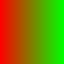

solid_blue: ../results/TEMPLATE-vision/fixtures/solid_blue.png  sha256=0a794b7ab2a9413ffcf2f0a16dc23804207ea7207fee4eb83a51f56d1639fcc7


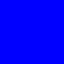

three_circles: ../results/TEMPLATE-vision/fixtures/three_circles.png  sha256=6e90b647d95b0a232df51dc29ea3af8c58b8c73d99e5d0dff3c3bfe14444dea5


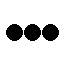

checkerboard: ../results/TEMPLATE-vision/fixtures/checkerboard.png  sha256=a9503fd441d5e71eeef592864db74e74af38617179df3fd1f0b5c49e2febd33c


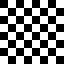

word_cmp: ../results/TEMPLATE-vision/fixtures/word_cmp.png  sha256=cc2f6f4886267d798d860eca61912916db270eae62d22c8dd74bb1d634b2bb90


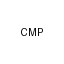

In [5]:
# --- Generate deterministic fixture images --------------------------------
import os
from io import BytesIO

from PIL import Image, ImageDraw, ImageFont
from IPython.display import Image as IPyImage, display

FIXTURES_DIR = os.path.join(RESULTS_DIR, "fixtures")
os.makedirs(FIXTURES_DIR, exist_ok=True)
SIZE = 64


def save_and_show(name, img):
    path = os.path.join(FIXTURES_DIR, f"{name}.png")
    img.save(path)
    digest = sha256_of(path)
    print(f"{name}: {path}  sha256={digest}")
    display(IPyImage(filename=path))
    return path, digest


fixtures = {}

# 1. 64x64 red-to-green horizontal gradient
grad = Image.new("RGB", (SIZE, SIZE))
for x in range(SIZE):
    t = x / (SIZE - 1)
    r = int(255 * (1 - t))
    g = int(255 * t)
    for y in range(SIZE):
        grad.putpixel((x, y), (r, g, 0))
fixtures["gradient_red_green"] = save_and_show("gradient_red_green", grad)

# 2. Solid blue
blue = Image.new("RGB", (SIZE, SIZE), (0, 0, 255))
fixtures["solid_blue"] = save_and_show("solid_blue", blue)

# 3. Three black circles on white
circles = Image.new("RGB", (SIZE, SIZE), (255, 255, 255))
d = ImageDraw.Draw(circles)
for cx in (14, 32, 50):
    d.ellipse((cx - 8, 24, cx + 8, 40), fill=(0, 0, 0))
fixtures["three_circles"] = save_and_show("three_circles", circles)

# 4. Checkerboard (8x8 squares)
checker = Image.new("RGB", (SIZE, SIZE), (255, 255, 255))
d = ImageDraw.Draw(checker)
cell = SIZE // 8
for row in range(8):
    for col in range(8):
        if (row + col) % 2 == 0:
            d.rectangle((col * cell, row * cell, (col + 1) * cell - 1, (row + 1) * cell - 1), fill=(0, 0, 0))
fixtures["checkerboard"] = save_and_show("checkerboard", checker)

# 5. The word "CMP" in a default font
word = Image.new("RGB", (SIZE, SIZE), (255, 255, 255))
d = ImageDraw.Draw(word)
font = ImageFont.load_default()
bbox = d.textbbox((0, 0), "CMP", font=font)
tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
d.text(((SIZE - tw) / 2 - bbox[0], (SIZE - th) / 2 - bbox[1]), "CMP", fill=(0, 0, 0), font=font)
fixtures["word_cmp"] = save_and_show("word_cmp", word)


### 2.2 Golden corpus (image prompts)

The correctness gate this club runs every vision patch against uses a
frozen 10-image corpus. The prompts and expected keywords below are
copied from that corpus's public schema (question and keyword only, no
file paths, no infrastructure detail).


In [6]:
golden_corpus = [
    ("img01_solid_red", "What is the single dominant color in this image? Answer with exactly one color word.", "red"),
    ("img02_solid_blue", "What is the single dominant color in this image? Answer with exactly one color word.", "blue"),
    ("img03_gradient_red_green", "This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma.", "red, green"),
    ("img04_gradient_blue_yellow", "This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma.", "blue, yellow"),
    ("img05_checkerboard", "This is an 8 by 8 checkerboard pattern. How many black squares does it contain? Answer with a number only.", "32"),
    ("img06_three_circles", "How many circles are shown in this image? Answer with a number only.", "3, three"),
    ("img07_five_squares", "How many squares are shown in this image? Answer with a number only.", "5, five"),
    ("img08_word_hello", "What single word is written in this image? Answer with just the word.", "hello"),
    ("img09_split_red_blue", "This image is split into a left half and a right half, each a solid color. What color is the LEFT half? Answer with one word.", "red"),
    ("img10_triangle", "What geometric shape is shown in this image? Answer with one word.", "triangle"),
]
render_table(["Id", "Question", "Expected keyword(s)"], golden_corpus)


| Id | Question | Expected keyword(s) |
|---|---|---|
| img01_solid_red | What is the single dominant color in this image? Answer with exactly one color word. | red |
| img02_solid_blue | What is the single dominant color in this image? Answer with exactly one color word. | blue |
| img03_gradient_red_green | This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma. | red, green |
| img04_gradient_blue_yellow | This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma. | blue, yellow |
| img05_checkerboard | This is an 8 by 8 checkerboard pattern. How many black squares does it contain? Answer with a number only. | 32 |
| img06_three_circles | How many circles are shown in this image? Answer with a number only. | 3, three |
| img07_five_squares | How many squares are shown in this image? Answer with a number only. | 5, five |
| img08_word_hello | What single word is written in this image? Answer with just the word. | hello |
| img09_split_red_blue | This image is split into a left half and a right half, each a solid color. What color is the LEFT half? Answer with one word. | red |
| img10_triangle | What geometric shape is shown in this image? Answer with one word. | triangle |

### 2.3 Functional gates

Each fixture is sent to an OpenAI-compatible endpoint (`VISION_ENDPOINT`,
default `http://127.0.0.1:18099/v1`; model id read from `/v1/models`) as a
`data:` URL, at `temperature=0`. Two controls run alongside the five
fixtures:

- **Negative control.** The solid-blue color question, sent with no
  image. A model that still answers "blue" is guessing, not looking.
- **Wrong-image control.** The gradient's color question, sent with the
  checkerboard image instead. A correct model should not answer
  "red"/"green" here.

**`vision-gates.json` schema** (one row per fixture or control):

```json
{
  "fixture": "solid_blue",
  "kind": "fixture | negative_control | wrong_image_control",
  "question": "...",
  "expected_keywords": ["blue"],
  "response_text": "...",
  "finish_reason": "stop",
  "usage": {"prompt_tokens": 0, "completion_tokens": 0},
  "keyword_match": true
}
```


In [7]:
import base64

GATE_QUESTIONS = {
    "gradient_red_green": ("This image is a color gradient. Name the two colors it blends between, separated by a comma.", ["red", "green"]),
    "solid_blue": ("What is the single dominant color in this image? Answer with exactly one color word.", ["blue"]),
    "three_circles": ("How many circles are shown in this image? Answer with a number only.", ["3", "three"]),
    "checkerboard": ("What pattern is shown in this image? Answer with one or two words.", ["checker", "checkerboard"]),
    "word_cmp": ("What text is written in this image? Answer with just the text.", ["cmp"]),
}


def data_url(path):
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    return f"data:image/png;base64,{b64}"


def call_vision_endpoint(question, image_path=None, model="unknown"):
    """Call the OpenAI-compatible vision endpoint. Only used when LIVE=True."""
    import requests

    content = [{"type": "text", "text": question}]
    if image_path is not None:
        content.insert(0, {"type": "image_url", "image_url": {"url": data_url(image_path)}})
    payload = {
        "model": model,
        "messages": [{"role": "user", "content": content}],
        "temperature": 0,
    }
    resp = requests.post(f"{VISION_ENDPOINT}/chat/completions", json=payload, timeout=120)
    resp.raise_for_status()
    return resp.json()


gate_rows = []
if LIVE:
    model_id = requests.get(f"{VISION_ENDPOINT}/models", timeout=30).json()["data"][0]["id"]
    print(f"model: {model_id}")
    for name, (question, keywords) in GATE_QUESTIONS.items():
        path, _ = fixtures[name]
        resp = call_vision_endpoint(question, path, model_id)
        text = resp["choices"][0]["message"]["content"]
        gate_rows.append({
            "fixture": name, "kind": "fixture", "question": question,
            "expected_keywords": keywords, "response_text": text,
            "finish_reason": resp["choices"][0]["finish_reason"], "usage": resp["usage"],
        })
    neg_q = GATE_QUESTIONS["solid_blue"][0]
    resp = call_vision_endpoint(neg_q, None, model_id)
    gate_rows.append({"fixture": "solid_blue", "kind": "negative_control", "question": neg_q,
                       "expected_keywords": ["blue"], "response_text": resp["choices"][0]["message"]["content"],
                       "finish_reason": resp["choices"][0]["finish_reason"], "usage": resp["usage"]})
    wrong_q = GATE_QUESTIONS["gradient_red_green"][0]
    resp = call_vision_endpoint(wrong_q, fixtures["checkerboard"][0], model_id)
    gate_rows.append({"fixture": "checkerboard", "kind": "wrong_image_control", "question": wrong_q,
                       "expected_keywords": ["red", "green"], "response_text": resp["choices"][0]["message"]["content"],
                       "finish_reason": resp["choices"][0]["finish_reason"], "usage": resp["usage"]})
    os.makedirs(RESULTS_DIR, exist_ok=True)
    json.dump({"rows": gate_rows}, open(os.path.join(RESULTS_DIR, "vision-gates.json"), "w"), indent=2)
elif gates is not None:
    gate_rows = gates["rows"]
else:
    print("no receipts yet: nothing to replay for the functional gates")


no receipts yet: nothing to replay for the functional gates


In [8]:
# --- Show each gate row: the image (if any), the question, the answer ----
from IPython.display import Image as IPyImage, display

if gate_rows:
    for row in gate_rows:
        print(f"[{row['kind']}] {row['fixture']}")
        print(f"  question : {row['question']}")
        img_path = os.path.join(FIXTURES_DIR, f"{row['fixture']}.png")
        if row["kind"] != "negative_control" and os.path.exists(img_path):
            display(IPyImage(filename=img_path))
        else:
            print("  (no image sent, this is the negative control)")
        print(f"  response : {row['response_text']}")
        print(f"  finish_reason: {row['finish_reason']}  usage: {row['usage']}")
        print()
else:
    print("no receipts yet: nothing to show")


no receipts yet: nothing to show


In [9]:
# --- Pass/fail: keyword match per fixture, overall verdict ---------------
if gate_rows:
    verdict_rows = []
    fixture_pass_count = 0
    fixture_total = 0
    for row in gate_rows:
        text = row["response_text"].lower()
        match = any(kw.lower() in text for kw in row["expected_keywords"])
        if row["kind"] == "fixture":
            fixture_total += 1
            fixture_pass_count += int(match)
            verdict = "PASS" if match else "FAIL"
        elif row["kind"] == "negative_control":
            verdict = "guessed without an image" if match else "did not guess (expected)"
        else:  # wrong_image_control
            verdict = "FAIL (answered as if it saw the wrong image)" if match else "PASS (did not match the wrong image)"
        verdict_rows.append((row["fixture"], row["kind"], match, verdict))
    render_table(["Fixture", "Kind", "Keyword match", "Verdict"], verdict_rows)
    overall = "PASS" if fixture_total and fixture_pass_count == fixture_total else "FAIL"
    print(f"Overall vision verdict: {overall} ({fixture_pass_count}/{fixture_total} fixtures matched)")
else:
    print("no receipts yet: nothing to grade")


no receipts yet: nothing to grade


### 2.4 Measurements

Same protocol as the text notebook: an uncached 2,941-token prefill x3, a
warm streaming TTFT x3, and a greedy 400-token concurrency ladder
(C1/C2/C4/C8/C16, 1 warmup + 3 measured reps), run twice: once with a
text-only prompt, once with a text+one-image prompt.


In [10]:
if ladder is not None and ladder.get("rows"):
    render_table(
        ["Prompt type", "Concurrency", "Aggregate median (tok/s)", "Per-request median (tok/s)", "Status"],
        ladder["rows"],
    )
else:
    print("no receipts yet: fill results/<experiment>/ladder.json with rows keyed by")
    print('  ["text-only" | "text+one-image"], concurrency, aggregate tok/s, per-request tok/s, status')


no receipts yet: fill results/<experiment>/ladder.json with rows keyed by
  ["text-only" | "text+one-image"], concurrency, aggregate tok/s, per-request tok/s, status


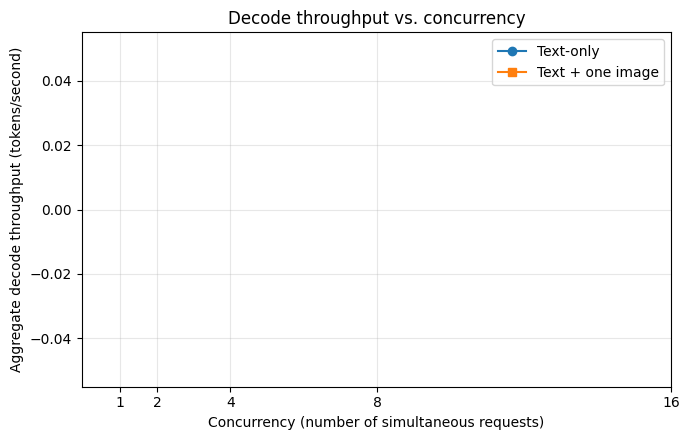

no receipts yet: chart is empty until ladder.json has passing rows


In [11]:
# --- Chart: tok/s vs concurrency, two series (text-only, text+one-image) -
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))

text_only_x, text_only_y = [], []  # concurrency, aggregate tok/s
with_image_x, with_image_y = [], []

if ladder is not None and ladder.get("rows"):
    for prompt_type, c, agg, _per_req, status in ladder["rows"]:
        if status != "PASS":
            continue
        if prompt_type == "text-only":
            text_only_x.append(c)
            text_only_y.append(agg)
        else:
            with_image_x.append(c)
            with_image_y.append(agg)

ax.plot(text_only_x, text_only_y, marker="o", label="Text-only")
ax.plot(with_image_x, with_image_y, marker="s", label="Text + one image")
ax.set_xlabel("Concurrency (number of simultaneous requests)")
ax.set_ylabel("Aggregate decode throughput (tokens/second)")
ax.set_title("Decode throughput vs. concurrency")
ax.set_xticks([1, 2, 4, 8, 16])
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()
if not (text_only_x or with_image_x):
    print("no receipts yet: chart is empty until ladder.json has passing rows")


In [12]:
# --- Per-request distribution table ---------------------------------------
if ladder is not None and ladder.get("per_request"):
    render_table(
        ["Prompt type", "Concurrency", "Per-request min (tok/s)", "Per-request median (tok/s)", "Per-request max (tok/s)"],
        ladder["per_request"],
    )
else:
    print("no receipts yet: fill results/<experiment>/ladder.json's per_request rows")


no receipts yet: fill results/<experiment>/ladder.json's per_request rows


## 3. Reproduce

**Hardware.** NVIDIA CMP 170HX or equivalent SM80 card, 64 GiB HBM2e per
card, card count matching the pinned PP partition above, PCIe Gen1/2 x16
per card, per-card power limit and forced airflow as stated in the pins
table.

**Run the image** (tag is a placeholder until a vision-capable image is
published):

```bash
docker run -d --name <container> --gpus '"device=0,1,2,3"' \
  -v <model-storage>/<model>@<revision>:/model:ro \
  --shm-size=16g -p 18099:8000 \
  ghcr.io/pixelml/club-170hx:<tag> \
  vllm serve /model --served-model-name <served-name> \
  --pipeline-parallel-size <ranks> --kv-cache-dtype <dtype> \
  --speculative-config '{"method":"dspark","num_speculative_tokens":<k>}'
```

**Snapshot.** Verify the checkpoint's shard count and total bytes against
a manifest before serving; never trust an unverified cache (see
`docs/LESSONS.md` section e).

**Bench command.** Run the same protocol as the text notebook against
`VISION_ENDPOINT`, and this notebook's fixture generation and gate cells
against the same endpoint with `LIVE=True`.

**Expected boot time.** Fill in from the receipt once a run exists; cold
NFS-backed loads on this fleet have measured in the tens of minutes for a
checkpoint of comparable size (see `docs/LESSONS.md` section e).

**One-command bring-up.** See the `vast-onstart.sh` script linked from
`docs/DOCKER-IMAGE.md` in the model's evidence repository.


### Reproduce skeleton: prerequisites

Fill this with a prerequisites cell, a weights-download cell, a
verification cell, and a rented-box path — the same skeleton the
published notebooks use.

- Card count and VRAM per card matching the pins table above.
- Any hardware unlock, driver version, and airflow requirement. Link
  [docs/INSTALLATION.md](../docs/INSTALLATION.md) and
  [docs/QC.md](../docs/QC.md).


### Download the weights

```bash
pip install -U huggingface_hub
hf download <model> --revision <revision> --local-dir <weights>
```


In [13]:
# Verify the local download before serving: shard count and one config field
# specific to this model. Replace the checks below with the real ones.
import json
import os

weights_dir = os.environ.get("MODEL_WEIGHTS_DIR", "<weights>")
if os.path.isdir(weights_dir):
    shards = [f for f in os.listdir(weights_dir) if f.endswith(".safetensors")]
    print(f"shard count : {len(shards)} (expect <n>)")
else:
    print(f"set MODEL_WEIGHTS_DIR to the download path to verify (got: {weights_dir})")


set MODEL_WEIGHTS_DIR to the download path to verify (got: <weights>)


### Rented box path (Vast.ai)

Link the evidence repository's `scripts/vast-onstart.sh` here, if one
exists, for a one-command bring-up on a rented box.


## 4. Appendix

<details>
<summary>Architecture detail, limitations, cost, and failure history (click to expand)</summary>

### 4.1 What changed vs. the text recipe

Vision input touches three places the text-only recipe does not:


In [14]:
vision_components = [
    ("Vision tower placement", "Runs on pipeline rank 0 only, ahead of the language-model layers, so its output feeds the first PP stage as extra hidden state"),
    ("Image-token routing mask across PP ranks", "A per-token boolean mask marks which sequence positions are image tokens; the MoE gate on every rank needs this mask (and, on some builds, raw input_ids) to route those positions correctly"),
    ("Input processor", "Expands each image placeholder token into the vision tower's patch-token count before the request reaches the model, changing prompt token accounting versus a text-only request"),
]
render_table(["Component", "What it does"], vision_components)


| Component | What it does |
|---|---|
| Vision tower placement | Runs on pipeline rank 0 only, ahead of the language-model layers, so its output feeds the first PP stage as extra hidden state |
| Image-token routing mask across PP ranks | A per-token boolean mask marks which sequence positions are image tokens; the MoE gate on every rank needs this mask (and, on some builds, raw input_ids) to route those positions correctly |
| Input processor | Expands each image placeholder token into the vision tower's patch-token count before the request reaches the model, changing prompt token accounting versus a text-only request |

In [15]:
sm80_fallbacks = [
    ("DeepGEMM (TF32 prenorm GEMM)", "Backend reports unavailable; the fallback gate checks for the package, not the architecture", "Triton fallback, selected by an architecture-aware check"),
    ("CuteDSL fused_indexer_q kernel", "NVVM backend does not compile for target sm_80", "Pure-torch fallback with matching RoPE and per-token scale numerics"),
    ("Triton fp8e4nv stores", "Compile error: type not supported on this architecture", "BF16 fallback, gated on compute capability < 9"),
    ("tilelang FP8 x FP4 GEMM", "Device assert; the kernel needs SM89 FP8 matrix-multiply", "FP4 dequant to BF16, then a BF16 GEMM; the vision tower runs BF16 attention"),
    ("fast_hadamard_transform CUDA extension", "Needed by the vision indexer path; the compiled extension does not run on SM80", "Pure-torch Sylvester Hadamard transform, checked exact against the reference"),
]
render_table(["Kernel", "Why it fails on Ampere (SM80)", "Replacement"], sm80_fallbacks)
print("Diff: <link to the patch set once it lands in the fork's commit history>")


| Kernel | Why it fails on Ampere (SM80) | Replacement |
|---|---|---|
| DeepGEMM (TF32 prenorm GEMM) | Backend reports unavailable; the fallback gate checks for the package, not the architecture | Triton fallback, selected by an architecture-aware check |
| CuteDSL fused_indexer_q kernel | NVVM backend does not compile for target sm_80 | Pure-torch fallback with matching RoPE and per-token scale numerics |
| Triton fp8e4nv stores | Compile error: type not supported on this architecture | BF16 fallback, gated on compute capability < 9 |
| tilelang FP8 x FP4 GEMM | Device assert; the kernel needs SM89 FP8 matrix-multiply | FP4 dequant to BF16, then a BF16 GEMM; the vision tower runs BF16 attention |
| fast_hadamard_transform CUDA extension | Needed by the vision indexer path; the compiled extension does not run on SM80 | Pure-torch Sylvester Hadamard transform, checked exact against the reference |

Diff: <link to the patch set once it lands in the fork's commit history>


### 4.2 Limitations and cost

- **Max prompt fit.** Fill in the largest prompt (text + image tokens)
  that fit inside `--max-model-len` for this recipe, from a receipt.
- **Image-count limit.** Fill in how many images one request can carry
  before context or memory limits are hit.
- **Thermals and power.** Report core/memory temperature range and
  per-card watts from telemetry, same convention as the text notebook.
- **Tokens per watt-hour.** Compute at the 180 W/card policy from the
  telemetry receipt: `completion_tokens / (watts * hours)`. Do not
  estimate this without a telemetry receipt.

### 4.3 What went wrong

Record every failed attempt here, in order, with its exact error class
and its fix or its dead end. Do not delete a failed configuration; a
negative result is evidence.


</details>
